# Polygonal Search PoC (444-inspired)

This notebook is a **concept PoC** for adaptive-width search.

- Fixed-width baselines: evaluate top-k moves by policy prior.
- Polygonal-444: dynamic width $n(s)$ from phase/volatility/uncertainty + 3 focus passes.
- Goal: compare decision quality vs compute cost on synthetic positions.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG = np.random.default_rng(444)
plt.style.use('seaborn-v0_8-whitegrid')

N_POSITIONS = 6000
print(f'Configured synthetic positions: {N_POSITIONS}')

Configured synthetic positions: 6000


In [2]:
def softmax(x):
    z = x - np.max(x)
    ex = np.exp(z)
    return ex / ex.sum()

def generate_position(rng):
    # phase_mg: 1.0 means middlegame-like, 0.0 means endgame-like
    phase_mg = float(np.clip(rng.beta(2.2, 1.8), 0.0, 1.0))
    volatility = float(np.clip(rng.beta(1.7, 2.4), 0.0, 1.0))
    uncertainty = float(np.clip(rng.beta(2.0, 2.0), 0.0, 1.0))

    # Wider legal move counts in complex positions
    base_moves = 8 + int(20 * phase_mg + 14 * volatility + rng.integers(0, 8))
    n_moves = int(np.clip(base_moves, 8, 45))

    # Hidden true quality of each move
    true_values = rng.normal(0.0, 1.0, size=n_moves)

    # Prior estimates (policy-like) are correlated but noisy
    prior_logits = true_values + rng.normal(0.0, 0.55 + 0.9 * uncertainty, size=n_moves)
    policy = softmax(prior_logits)

    best_idx = int(np.argmax(true_values))
    return {
        'phase_mg': phase_mg,
        'volatility': volatility,
        'uncertainty': uncertainty,
        'n_moves': n_moves,
        'true_values': true_values,
        'policy': policy,
        'best_idx': best_idx,
    }

In [5]:
def choose_topk_by_policy(pos, k):
    order = np.argsort(-pos['policy'])
    return order[: min(k, pos['n_moves'])]

def evaluate_selected(pos, selected, rng, sigma):
    # Simulated deeper evaluation for selected moves
    tv = pos['true_values'][selected]
    return tv + rng.normal(0.0, sigma, size=len(selected))

def run_fixed_k(pos, k, rng):
    selected = choose_topk_by_policy(pos, k)
    deep_scores = evaluate_selected(pos, selected, rng, sigma=0.18)
    choice = int(selected[np.argmax(deep_scores)])
    success = int(choice == pos['best_idx'])
    cost = float(len(selected))
    return success, cost, len(selected)

def polygonal_width_444(pos):
    # 444-inspired dynamic width: wider in middlegame/volatile/uncertain positions
    raw = 3.2 + 5.2 * pos['phase_mg'] + 3.5 * pos['volatility'] + 2.8 * pos['uncertainty']
    n = int(round(raw))
    return int(np.clip(n, 4, 14))

def run_polygonal_444(pos, rng):
    n0 = min(polygonal_width_444(pos), pos['n_moves'])
    shortlist = choose_topk_by_policy(pos, n0)

    seen = set(int(x) for x in shortlist)
    scores = {int(m): 0.0 for m in shortlist}

    # 3 focus passes (the "3 times over" intuition)
    sigmas = [0.28, 0.20, 0.14]
    for p, sigma in enumerate(sigmas, start=1):
        focus_n = max(4, n0 - (p - 1))

        # Evaluate current focused set
        eval_set = np.array(sorted(scores.keys()), dtype=int)
        deep = evaluate_selected(pos, eval_set, rng, sigma=sigma)
        for m, s in zip(eval_set, deep):
            scores[int(m)] = 0.70 * scores[int(m)] + 0.30 * float(s)

        # Safety exploration: one extra candidate from outside current focus
        order = np.argsort(-pos['policy'])
        outside = [int(m) for m in order if int(m) not in scores]
        if outside:
            m = outside[0]
            s = float(evaluate_selected(pos, np.array([m]), rng, sigma=sigma + 0.06)[0])
            scores[m] = s
            seen.add(m)

        # Keep top focus_n by fused score
        ranked = sorted(scores.items(), key=lambda kv: kv[1], reverse=True)
        scores = {m: sc for m, sc in ranked[:focus_n]}

    final_choice = max(scores.items(), key=lambda kv: kv[1])[0]
    success = int(final_choice == pos['best_idx'])

    # Cost proxy: weighted passes + exploration, intentionally comparable to fixed-k scale
    pass_work = 0.42 * (n0 + max(4, n0 - 1) + max(4, n0 - 2))
    explore_work = 0.75 * max(0, len(seen) - n0)
    cost = float(pass_work + explore_work)

    return success, cost, n0

In [6]:
strategies = {
    'Fixed-4': lambda p, r: run_fixed_k(p, 4, r),
    'Fixed-8': lambda p, r: run_fixed_k(p, 8, r),
    'Fixed-12': lambda p, r: run_fixed_k(p, 12, r),
    'Polygonal-444': lambda p, r: run_polygonal_444(p, r),
}

rows = []
for i in range(N_POSITIONS):
    pos = generate_position(RNG)
    for name, fn in strategies.items():
        success, cost, n0 = fn(pos, RNG)
        rows.append({
            'strategy': name,
            'success': success,
            'cost': cost,
            'phase_mg': pos['phase_mg'],
            'volatility': pos['volatility'],
            'uncertainty': pos['uncertainty'],
            'n_moves': pos['n_moves'],
            'poly_n0': n0 if name == 'Polygonal-444' else np.nan,
        })

df = pd.DataFrame(rows)
summary = (
    df.groupby('strategy', as_index=False)
      .agg(accuracy=('success', 'mean'), avg_cost=('cost', 'mean'))
      .sort_values('avg_cost')
)
summary['efficiency'] = summary['accuracy'] / summary['avg_cost']
summary

,strategy,accuracy,avg_cost,efficiency
1,Fixed-4,0.616667,4.00000,0.154167
2,Fixed-8,0.726833,8.00000,0.090854
3,Polygonal-444,0.764167,10.74586,0.071113
0,Fixed-12,0.784500,11.99900,0.065380


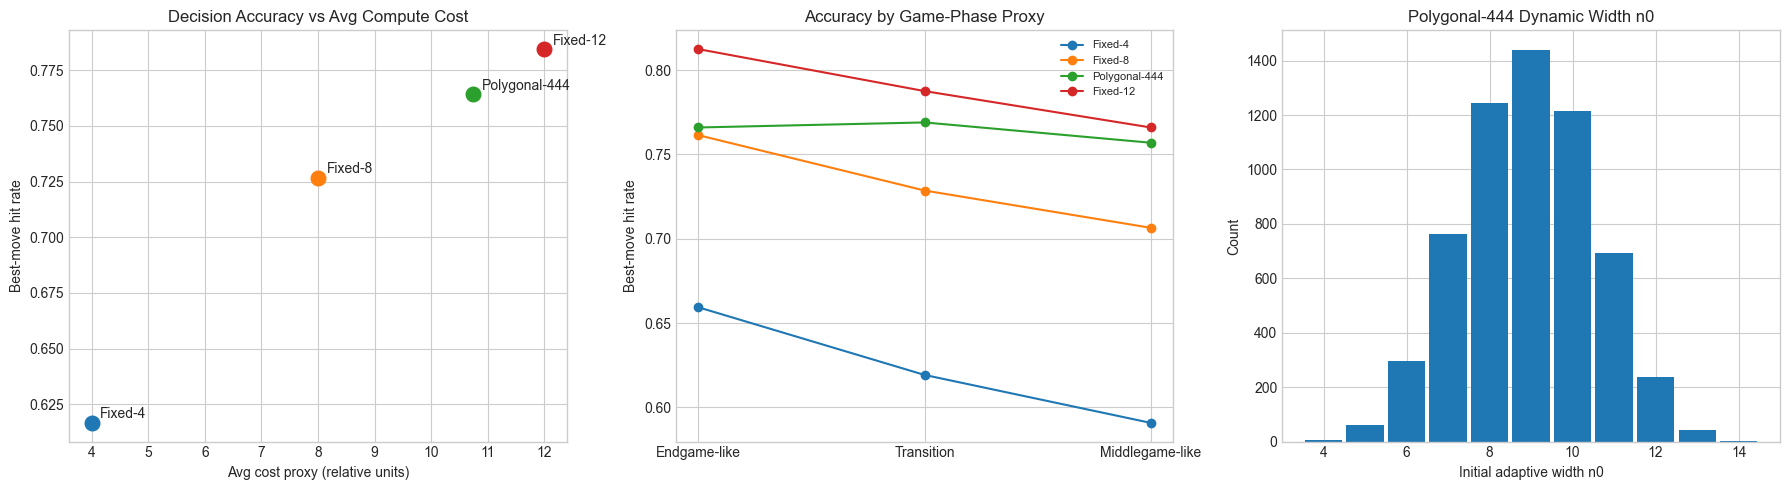

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy vs cost
ax = axes[0]
for _, r in summary.iterrows():
    ax.scatter(r['avg_cost'], r['accuracy'], s=110)
    ax.text(r['avg_cost'] + 0.15, r['accuracy'] + 0.002, r['strategy'])
ax.set_title('Decision Accuracy vs Avg Compute Cost')
ax.set_xlabel('Avg cost proxy (relative units)')
ax.set_ylabel('Best-move hit rate')

# Phase-wise accuracy
ax = axes[1]
phase_bins = pd.cut(df['phase_mg'], bins=[0, 0.33, 0.66, 1.0], labels=['Endgame-like', 'Transition', 'Middlegame-like'])
phase_view = df.assign(phase_bin=phase_bins)
phase_acc = phase_view.groupby(['phase_bin', 'strategy'])['success'].mean().reset_index()
for name in summary['strategy']:
    d = phase_acc[phase_acc['strategy'] == name]
    ax.plot(d['phase_bin'].astype(str), d['success'], marker='o', label=name)
ax.set_title('Accuracy by Game-Phase Proxy')
ax.set_ylabel('Best-move hit rate')
ax.legend(fontsize=8)

# Polygon width distribution
ax = axes[2]
poly = df[df['strategy'] == 'Polygonal-444']['poly_n0'].dropna()
ax.hist(poly, bins=np.arange(poly.min() - 0.5, poly.max() + 1.5, 1), rwidth=0.9)
ax.set_title('Polygonal-444 Dynamic Width n0')
ax.set_xlabel('Initial adaptive width n0')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [8]:
poly_df = df[df['strategy'] == 'Polygonal-444'].copy()
poly_df['phase_bin'] = pd.cut(poly_df['phase_mg'], bins=[0, 0.33, 0.66, 1.0], labels=['Endgame-like', 'Transition', 'Middlegame-like'])
poly_stats = poly_df.groupby('phase_bin', as_index=False).agg(
    mean_n0=('poly_n0', 'mean'),
    p25_n0=('poly_n0', lambda x: float(np.percentile(x, 25))),
    p75_n0=('poly_n0', lambda x: float(np.percentile(x, 75))),
    mean_moves=('n_moves', 'mean'),
)
poly_stats

,phase_bin,mean_n0,p25_n0,p75_n0,mean_moves
0,Endgame-like,7.177596,6.0,8.0,21.075592
1,Transition,8.658214,8.0,9.0,26.817143
2,Middlegame-like,10.205043,9.0,11.0,32.668887


## Reading This PoC

- This is a synthetic experiment, so absolute numbers are not engine Elo.
- Use it to test behavior of adaptive width schedules and 3-pass focus logic.
- Next upgrade: swap synthetic generator with real positions + your policy/eval outputs.

## Experiment 2: Real Chess Positions (python-chess)

This experiment replaces synthetic position generation with random legal chess positions from `python-chess`.

- Move candidates are real legal moves.
- "True" move value is a lightweight surrogate from board features after making each move.
- Policy prior is a noisy approximation of that value.
- We compare fixed-width baselines vs Polygonal-444 on this real-position setup.

In [ ]:
import chess

PIECE_VALUES = {
    chess.PAWN: 100,
    chess.KNIGHT: 320,
    chess.BISHOP: 330,
    chess.ROOK: 500,
    chess.QUEEN: 900,
}

def eval_white_cp(board: chess.Board) -> float:
    # Simple static surrogate: material + mobility + king pressure
    score = 0.0
    for sq, piece in board.piece_map().items():
        if piece.piece_type == chess.KING:
            continue
        val = PIECE_VALUES[piece.piece_type]
        score += val if piece.color == chess.WHITE else -val

    # Mobility differential (small term)
    side = board.turn
    own_mob = board.legal_moves.count()
    board.turn = not side
    opp_mob = board.legal_moves.count()
    board.turn = side
    score += 1.2 * (own_mob - opp_mob) if side == chess.WHITE else 1.2 * (opp_mob - own_mob)

    # King-check pressure
    if board.is_check():
        score += -35.0 if board.turn == chess.WHITE else 35.0

    return score

def random_playout_position(rng: np.random.Generator, min_ply=8, max_ply=70) -> chess.Board:
    board = chess.Board()
    target = int(rng.integers(min_ply, max_ply + 1))
    for _ in range(target):
        if board.is_game_over(claim_draw=True):
            break
        moves = list(board.legal_moves)
        if not moves:
            break
        mv = moves[int(rng.integers(0, len(moves)))]
        board.push(mv)
    return board

def real_position_from_board(board: chess.Board, rng: np.random.Generator):
    legal = list(board.legal_moves)
    n_moves = len(legal)

    mover_is_white = board.turn
    true_values = np.zeros(n_moves, dtype=float)
    tactical = np.zeros(n_moves, dtype=float)

    for i, mv in enumerate(legal):
        b = board.copy(stack=False)
        is_capture = b.is_capture(mv)
        gives_check = b.gives_check(mv)
        promo = mv.promotion is not None

        b.push(mv)
        ev_white = eval_white_cp(b)
        mover_ev = ev_white if mover_is_white else -ev_white

        tac_bonus = 0.0
        if is_capture:
            tac_bonus += 25.0
        if gives_check:
            tac_bonus += 22.0
        if promo:
            tac_bonus += 35.0

        tactical[i] = tac_bonus
        true_values[i] = mover_ev + tac_bonus + rng.normal(0.0, 12.0)

    # Build prior with uncertainty noise
    centered = true_values - np.mean(true_values)
    temp = 70.0 + 20.0 * (1.0 - min(1.0, n_moves / 35.0))
    prior_logits = centered / temp + rng.normal(0.0, 0.35, size=n_moves)
    policy = softmax(prior_logits)

    # Signals for 444
    non_king_count = sum(1 for p in board.piece_map().values() if p.piece_type != chess.KING)
    phase_mg = float(np.clip((non_king_count - 6) / 24.0, 0.0, 1.0))

    forcing_ratio = float(np.mean(tactical > 0.0)) if n_moves else 0.0
    volatility = float(np.clip(0.35 + 0.9 * forcing_ratio, 0.0, 1.0))

    entropy = -np.sum(policy * np.log(policy + 1e-12))
    uncertainty = float(np.clip(entropy / np.log(max(2, n_moves)), 0.0, 1.0))

    top2 = np.sort(policy)[-2:]
    top_gap = float(top2[-1] - top2[-2]) if len(top2) == 2 else 0.0
    stability_alert = float(np.clip(1.0 - 6.0 * top_gap, 0.0, 1.0))

    best_idx = int(np.argmax(true_values))
    return {
        'phase_mg': phase_mg,
        'volatility': volatility,
        'uncertainty': uncertainty,
        'stability_alert': stability_alert,
        'n_moves': n_moves,
        'true_values': true_values,
        'policy': policy,
        'best_idx': best_idx,
        'fen': board.fen(),
    }

def build_real_dataset(n_positions=1200, seed=2026):
    rng = np.random.default_rng(seed)
    data = []
    while len(data) < n_positions:
        b = random_playout_position(rng)
        if b.is_game_over(claim_draw=True):
            continue
        if b.legal_moves.count() < 6:
            continue
        data.append(real_position_from_board(b, rng))
    return data

# Build one reusable real-position dataset
real_positions = build_real_dataset(n_positions=1200, seed=2026)
print(f"Real positions ready: {len(real_positions)}")
print(f"Example FEN: {real_positions[0]['fen']}")

real_rows = []
real_strategies = {
    'Fixed-4': lambda p, r: run_fixed_k(p, 4, r),
    'Fixed-8': lambda p, r: run_fixed_k(p, 8, r),
    'Fixed-12': lambda p, r: run_fixed_k(p, 12, r),
    'Polygonal-444': lambda p, r: run_polygonal_444(p, r),
}

r_rng = np.random.default_rng(777)
for pos in real_positions:
    for name, fn in real_strategies.items():
        success, cost, n0 = fn(pos, r_rng)
        real_rows.append({
            'strategy': name,
            'success': success,
            'cost': cost,
            'phase_mg': pos['phase_mg'],
            'volatility': pos['volatility'],
            'uncertainty': pos['uncertainty'],
            'stability_alert': pos['stability_alert'],
            'n_moves': pos['n_moves'],
            'poly_n0': n0 if name == 'Polygonal-444' else np.nan,
        })

real_df = pd.DataFrame(real_rows)
real_summary = (
    real_df.groupby('strategy', as_index=False)
           .agg(accuracy=('success', 'mean'), avg_cost=('cost', 'mean'))
           .sort_values('avg_cost')
)
real_summary['efficiency'] = real_summary['accuracy'] / real_summary['avg_cost']
real_summary

## Experiment 3: 444 Signal Ablation (Uncertainty + Stability)

This ablation tests which 444 signal contributes most to adaptive width quality.

Signals in width formula:
- `phase_mg`
- `volatility`
- `uncertainty`
- `stability_alert` (high means unstable policy ranking)

Each ablation removes one signal while keeping the others active.

In [ ]:
def polygonal_width_ablation(pos, use_phase=True, use_vol=True, use_unc=True, use_stab=True):
    raw = 3.4
    if use_phase:
        raw += 4.8 * pos['phase_mg']
    if use_vol:
        raw += 3.3 * pos['volatility']
    if use_unc:
        raw += 2.7 * pos['uncertainty']
    if use_stab:
        raw += 2.0 * pos['stability_alert']
    return int(np.clip(round(raw), 4, 14))

def run_polygonal_ablation(pos, rng, use_phase=True, use_vol=True, use_unc=True, use_stab=True):
    n0 = min(polygonal_width_ablation(pos, use_phase, use_vol, use_unc, use_stab), pos['n_moves'])
    shortlist = choose_topk_by_policy(pos, n0)

    seen = set(int(x) for x in shortlist)
    scores = {int(m): 0.0 for m in shortlist}

    sigmas = [0.28, 0.20, 0.14]
    for p, sigma in enumerate(sigmas, start=1):
        focus_n = max(4, n0 - (p - 1))
        eval_set = np.array(sorted(scores.keys()), dtype=int)
        deep = evaluate_selected(pos, eval_set, rng, sigma=sigma)

        for m, s in zip(eval_set, deep):
            scores[int(m)] = 0.70 * scores[int(m)] + 0.30 * float(s)

        order = np.argsort(-pos['policy'])
        outside = [int(m) for m in order if int(m) not in scores]
        if outside:
            m = outside[0]
            s = float(evaluate_selected(pos, np.array([m]), rng, sigma=sigma + 0.06)[0])
            scores[m] = s
            seen.add(m)

        ranked = sorted(scores.items(), key=lambda kv: kv[1], reverse=True)
        scores = {m: sc for m, sc in ranked[:focus_n]}

    final_choice = max(scores.items(), key=lambda kv: kv[1])[0]
    success = int(final_choice == pos['best_idx'])
    pass_work = 0.42 * (n0 + max(4, n0 - 1) + max(4, n0 - 2))
    explore_work = 0.75 * max(0, len(seen) - n0)
    cost = float(pass_work + explore_work)
    return success, cost, n0

ablations = {
    'Full-444': dict(use_phase=True, use_vol=True, use_unc=True, use_stab=True),
    'No-phase': dict(use_phase=False, use_vol=True, use_unc=True, use_stab=True),
    'No-volatility': dict(use_phase=True, use_vol=False, use_unc=True, use_stab=True),
    'No-uncertainty': dict(use_phase=True, use_vol=True, use_unc=False, use_stab=True),
    'No-stability': dict(use_phase=True, use_vol=True, use_unc=True, use_stab=False),
}

ab_rows = []
ab_rng = np.random.default_rng(1313)
for pos in real_positions:
    for name, cfg in ablations.items():
        success, cost, n0 = run_polygonal_ablation(pos, ab_rng, **cfg)
        ab_rows.append({
            'variant': name,
            'success': success,
            'cost': cost,
            'n0': n0,
            'phase_mg': pos['phase_mg'],
            'volatility': pos['volatility'],
            'uncertainty': pos['uncertainty'],
            'stability_alert': pos['stability_alert'],
        })

ab_df = pd.DataFrame(ab_rows)
ab_summary = (
    ab_df.groupby('variant', as_index=False)
         .agg(accuracy=('success', 'mean'), avg_cost=('cost', 'mean'), mean_n0=('n0', 'mean'))
)
base_acc = float(ab_summary.loc[ab_summary['variant'] == 'Full-444', 'accuracy'].iloc[0])
ab_summary['delta_acc_vs_full'] = ab_summary['accuracy'] - base_acc
ab_summary.sort_values('delta_acc_vs_full', ascending=True)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Real-position strategy comparison
ax = axes[0]
for _, r in real_summary.iterrows():
    ax.scatter(r['avg_cost'], r['accuracy'], s=110)
    ax.text(r['avg_cost'] + 0.12, r['accuracy'] + 0.002, r['strategy'])
ax.set_title('Real Positions: Accuracy vs Cost')
ax.set_xlabel('Avg cost proxy')
ax.set_ylabel('Best-move hit rate')

# Ablation delta accuracy
ax = axes[1]
plot_df = ab_summary.sort_values('delta_acc_vs_full')
colors = ['tab:gray' if v != 'Full-444' else 'tab:green' for v in plot_df['variant']]
ax.barh(plot_df['variant'], plot_df['delta_acc_vs_full'], color=colors)
ax.axvline(0.0, color='black', linewidth=1)
ax.set_title('Ablation: Delta Accuracy vs Full-444')
ax.set_xlabel('Accuracy delta')

plt.tight_layout()
plt.show()

print('Real-position summary:')
display(real_summary)
print('\nAblation summary:')
display(ab_summary.sort_values('delta_acc_vs_full', ascending=True))